# 21 cm × Galaxy Cross-Correlation — Part 3: Power Spectra & SNR
## HERA × Euclid (Lightcone)

This notebook loads the simulation outputs produced by `run_simulation.py`
and performs all post-simulation calculations:

1. **2D cylindrical power spectra** $P_{21}$, $P_{\rm gal}$, $P_{21\times{\rm gal}}$
2. **Foreground wedge geometry** — horizon and HERA FoV wedge lines
3. **Photo-$z$ damping** — Euclid photometric-redshift smearing along LOS
4. **SNR map** — per-mode and cumulative detection significance

**Prerequisites:** run `run_simulation.py` (or `sbatch submit_job.sh`) first
to generate `outputs/lightcone_data.h5`.

**References:**
- Davies, Mesinger & Murray (2025) — [arXiv:2504.17254](https://arxiv.org/abs/2504.17254)
- Gagnon-Hartman, Davies & Mesinger (2025) — [arXiv:2502.20447](https://arxiv.org/abs/2502.20447)
- La Plante et al. (2023) — [arXiv:2205.09770](https://arxiv.org/abs/2205.09770)
- Euclid Collaboration (2022) — [arXiv:2108.01201](https://arxiv.org/abs/2108.01201)


## Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.ndimage import generic_filter
import h5py
import warnings

warnings.filterwarnings('ignore')

# ── Matplotlib defaults ──────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":      300,
    "font.size":       12,
    "axes.labelsize":  13,
    "legend.fontsize": 10,
    "axes.grid":       False,
})


## Configuration — set path to simulation output

Edit `OUTPUT_FILE` if you saved the HDF5 to a different location.


In [2]:
# ── Path to simulation output (produced by run_simulation.py) ────────────────
OUTPUT_FILE = "../outputs/lightcone_data.h5"

# ── Load all fields and metadata from HDF5 ───────────────────────────────────
with h5py.File(OUTPUT_FILE, 'r') as f:

    # Simulation fields
    brightness_temp_field = f['brightness_temp_field'][:]
    neutral_fraction      = f['neutral_fraction'][:]
    galaxy_overdensity    = f['galaxy_overdensity'][:]

    # LOS geometry
    lc_redshifts = f['lc_redshifts'][:]

    # Halo catalogue (empty arrays when 21cmFAST was not used)
    sfr_cat        = f['halo_catalog/sfr'][:]
    halo_masses    = f['halo_catalog/halo_masses'][:]
    halo_coords    = f['halo_catalog/halo_coords'][:]
    stellar_masses = f['halo_catalog/stellar_masses'][:]

    # Scalar metadata
    HII_DIM             = int(f.attrs['HII_DIM'])
    BOX_LEN             = float(f.attrs['BOX_LEN'])
    N_z                 = int(f.attrs['N_z'])
    L_los               = float(f.attrs['L_los'])
    cell_size           = float(f.attrs['cell_size'])
    z_min               = float(f.attrs['z_min'])
    z_max               = float(f.attrs['z_max'])
    z_obs               = float(f.attrs['z_obs'])
    galaxy_bias         = float(f.attrs['galaxy_bias'])
    mean_galaxy_density = float(f.attrs['mean_galaxy_density'])
    photoz_uncertainty  = float(f.attrs['photoz_uncertainty'])
    M_UV_limit          = float(f.attrs['M_UV_limit'])
    OMEGA_M_0           = float(f.attrs['OMEGA_M_0'])
    HUBBLE_CONSTANT     = float(f.attrs['HUBBLE_CONSTANT'])
    SPEED_OF_LIGHT_KMS  = float(f.attrs['SPEED_OF_LIGHT_KMS'])
    SPEED_OF_LIGHT_MPS  = float(f.attrs['SPEED_OF_LIGHT_MPS'])
    F_21_MHZ            = float(f.attrs['F_21_MHZ'])
    F_21_HZ             = float(f.attrs['F_21_HZ'])
    HERA_DISH_DIAMETER  = float(f.attrs['HERA_DISH_DIAMETER'])
    integration_time    = float(f.attrs['integration_time'])
    bandwidth           = float(f.attrs['bandwidth'])
    wedge_buffer        = float(f.attrs['wedge_buffer'])
    n_bins_perp         = int(f.attrs['n_bins_perp'])
    n_bins_parallel     = int(f.attrs['n_bins_parallel'])

# ── Hubble parameter (needed for wedge/noise calculations) ───────────────────
def hubble_parameter(z):
    """H(z) for flat ΛCDM  [km s⁻¹ Mpc⁻¹]."""
    return HUBBLE_CONSTANT * np.sqrt(OMEGA_M_0 * (1 + z)**3 + (1 - OMEGA_M_0))


print(f'Loaded: brightness_temp_field {brightness_temp_field.shape}')
print(f'        neutral_fraction       {neutral_fraction.shape}')
print(f'        galaxy_overdensity     {galaxy_overdensity.shape}')
print(f'        z = {z_min} -> {z_max},  z_obs = {z_obs}')
print(f'        galaxy_bias = {galaxy_bias:.3f}')
print(f'        halo_catalog/sfr       {sfr_cat.shape}  ({(sfr_cat > 0).sum()} halos with SFR > 0)')


Loaded: brightness_temp_field (128, 128, 100)
        neutral_fraction       (128, 128, 100)
        galaxy_overdensity     (128, 128, 100)
        z = 6.995 -> 7.005,  z_obs = 7.0
        galaxy_bias = 33.389
        halo_catalog/sfr       (114289081,)  (114289081 halos with SFR > 0)


## 1  Compute the 2D cylindrical power spectra

The lightcone box is non-cubic: $(HII\_DIM, HII\_DIM, N_z)$ with transverse
size $L_\perp = BOX\_LEN$ and LOS size $L_{\rm LOS}$. The function below
handles this by using separate cell sizes and fundamental modes for the
transverse and LOS directions.

We compute:
- $P_{21}(k_\perp, k_\parallel)$ — 21 cm auto-power
- $P_{\rm gal}(k_\perp, k_\parallel)$ — galaxy auto-power
- $P_{21 \times \rm gal}(k_\perp, k_\parallel)$ — cross-power (expected to be **negative** on large scales)


In [3]:
def compute_cylindrical_cross_power(
    field_a,
    field_b,
    box_len_perp,
    box_len_los,
    n_bins_perp=20,
    n_bins_parallel=20,
):
    """
    Compute the 2D cylindrical cross-power spectrum P(k_perp, k_parallel)
    for a non-cubic (lightcone) box.

    Parameters
    ----------
    field_a, field_b : ndarray, shape (N, N, N_z)
        Real-space 3D fields. Transverse dimensions are equal (N × N);
        the LOS dimension N_z may differ.
    box_len_perp : float
        Comoving side length of the transverse box  [Mpc].
    box_len_los : float
        Comoving length of the LOS axis  [Mpc].
    n_bins_perp, n_bins_parallel : int
        Number of log-spaced bins along k_perp and k_parallel.

    Returns
    -------
    k_perp_centres     : 1D array  [Mpc⁻¹]
    k_parallel_centres : 1D array  [Mpc⁻¹]
    power_2d           : 2D array, shape (n_bins_perp, n_bins_parallel)
    mode_counts        : 2D array, shape (n_bins_perp, n_bins_parallel)
    """
    N   = field_a.shape[0]   # transverse cells
    N_z = field_a.shape[2]   # LOS cells

    dx     = box_len_perp / N    # transverse cell size  [Mpc]
    dz     = box_len_los  / N_z  # LOS cell size  [Mpc]
    volume = box_len_perp**2 * box_len_los

    # ── Fourier transforms ────────────────────────────────────────────
    ft_factor = dx * dx * dz
    fourier_a = np.fft.fftn(field_a) * ft_factor
    fourier_b = np.fft.fftn(field_b) * ft_factor
    power_3d  = (fourier_a * np.conj(fourier_b)).real / volume

    # ── Wavenumber grids ──────────────────────────────────────────────
    kx = np.fft.fftfreq(N,   d=dx) * 2 * np.pi
    ky = np.fft.fftfreq(N,   d=dx) * 2 * np.pi
    kz = np.fft.fftfreq(N_z, d=dz) * 2 * np.pi
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')

    k_perp_3d     = np.sqrt(KX**2 + KY**2)
    k_parallel_3d = np.abs(KZ)

    # ── Bin edges (log-spaced, starting below first discrete mode) ────
    dk_perp = 2 * np.pi / box_len_perp
    dk_par  = 2 * np.pi / box_len_los

    k_max_perp = np.sqrt(2) * np.abs(kx).max() * 1.05
    k_max_par  = np.abs(kz).max() * 1.05

    k_perp_edges = np.logspace(
        np.log10(0.5 * dk_perp), np.log10(k_max_perp), n_bins_perp + 1
    )
    k_par_edges = np.logspace(
        np.log10(0.5 * dk_par), np.log10(k_max_par), n_bins_parallel + 1
    )

    # ── Bin the 3D power into 2D ──────────────────────────────────────
    power_2d    = np.zeros((n_bins_perp, n_bins_parallel))
    mode_counts = np.zeros_like(power_2d)

    bin_perp = np.digitize(k_perp_3d.ravel(), k_perp_edges)    - 1
    bin_par  = np.digitize(k_parallel_3d.ravel(), k_par_edges) - 1
    power_flat = power_3d.ravel()

    inside = (
        (bin_perp >= 0) & (bin_perp < n_bins_perp) &
        (bin_par  >= 0) & (bin_par  < n_bins_parallel)
    )
    np.add.at(power_2d,    (bin_perp[inside], bin_par[inside]), power_flat[inside])
    np.add.at(mode_counts, (bin_perp[inside], bin_par[inside]), 1)

    power_2d = np.divide(
        power_2d, mode_counts,
        where=mode_counts > 0,
        out=np.full_like(power_2d, np.nan),
    )

    k_perp_centres = np.sqrt(k_perp_edges[:-1] * k_perp_edges[1:])
    k_par_centres  = np.sqrt(k_par_edges[:-1]  * k_par_edges[1:])

    return k_perp_centres, k_par_centres, power_2d, mode_counts


# ======================================================================
#  Compute all three 2D power spectra
# ======================================================================
T21_fluctuations    = brightness_temp_field - brightness_temp_field.mean()
galaxy_fluctuations = galaxy_overdensity

print('Computing 2D cylindrical power spectra …')

k_perp, k_parallel, P_21cm_auto, mode_counts = compute_cylindrical_cross_power(
    T21_fluctuations, T21_fluctuations,
    BOX_LEN, L_los, n_bins_perp, n_bins_parallel,
)
_, _, P_galaxy_auto, _ = compute_cylindrical_cross_power(
    galaxy_fluctuations, galaxy_fluctuations,
    BOX_LEN, L_los, n_bins_perp, n_bins_parallel,
)
_, _, P_cross, _ = compute_cylindrical_cross_power(
    T21_fluctuations, galaxy_fluctuations,
    BOX_LEN, L_los, n_bins_perp, n_bins_parallel,
)

large_scale_mean = np.nanmean(P_cross[:5, :5])
n_empty          = np.sum(mode_counts == 0)
print(f'k_perp     range : [{k_perp.min():.4f},  {k_perp.max():.3f}] Mpc⁻¹')
print(f'k_parallel range : [{k_parallel.min():.4f},  {k_parallel.max():.3f}] Mpc⁻¹')
print(f'Empty bins       : {n_empty} / {mode_counts.size}')
print(
    f'Large-scale cross-spectrum sign: '
    f'{"NEGATIVE (anti-correlated) ✓" if large_scale_mean < 0 else "POSITIVE"}'
)


Computing 2D cylindrical power spectra …
k_perp     range : [0.0140,  2.046] Mpc⁻¹
k_parallel range : [0.0176,  1.468] Mpc⁻¹
Empty bins       : 145 / 400
Large-scale cross-spectrum sign: NEGATIVE (anti-correlated) ✓


## 2  Plot the 2D cylindrical power spectra

Three panels showing $P_{21}$, $P_{\rm gal}$, and the signed cross-power
$P_{21\times\rm gal}$ in $(k_\perp,\, k_\parallel)$ space, with the
foreground horizon and HERA primary-beam wedge overlaid.


Reference z_obs        : 7.0
Observed wavelength    : λ = 1.690 m
Comoving distance      : D_c = 8821 Mpc
Horizon wedge slope    : m = 3.151
HERA beam half-angle   : θ = 6.9°
HERA FoV wedge slope   : m_FoV = 0.379


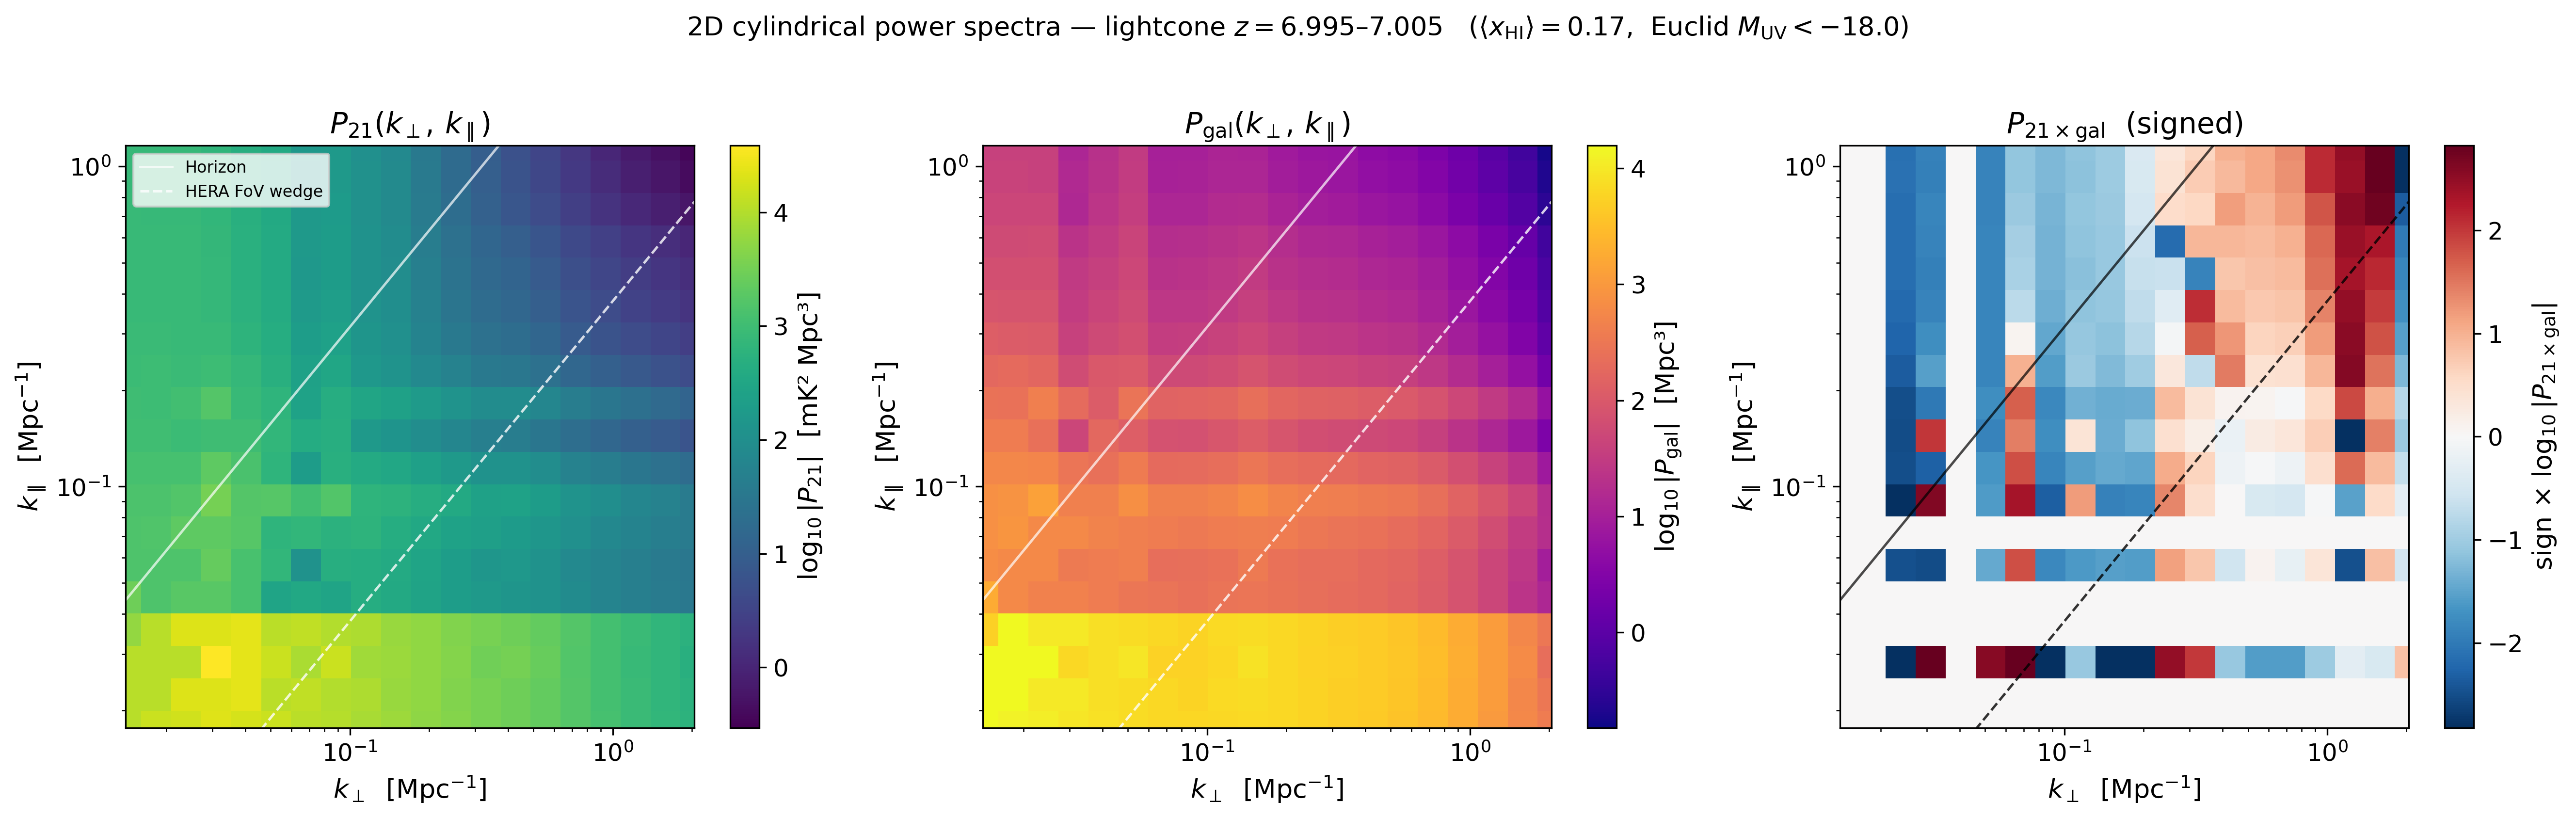

In [4]:
def fill_nan_nearest(arr):
    """Replace NaN pixels with the nearest non-NaN neighbour (display only)."""
    mask = np.isnan(arr)
    if not mask.any():
        return arr
    filled = arr.copy()
    for _ in range(max(arr.shape)):
        if not np.isnan(filled).any():
            break
        kernel_filled = generic_filter(filled, np.nanmean, size=3, mode='nearest')
        filled = np.where(np.isnan(filled), kernel_filled, filled)
    return filled


# ======================================================================
#  Foreground wedge geometry  (Thyagarajan+2015; La Plante+2023, Eq. 10)
#  Evaluated at the reference redshift z_obs
# ======================================================================
Hz_obs = hubble_parameter(z_obs)   # H(z_obs)  [km s⁻¹ Mpc⁻¹]

comoving_distance_obs, _ = quad(
    lambda z_: SPEED_OF_LIGHT_KMS / hubble_parameter(z_), 0, z_obs
)   # D_c(z_obs)  [Mpc]

lambda_obs = SPEED_OF_LIGHT_MPS * (1 + z_obs) / F_21_HZ   # observed wavelength  [m]

# Horizon wedge slope
horizon_slope = (
    lambda_obs * comoving_distance_obs * F_21_HZ * Hz_obs
    / (SPEED_OF_LIGHT_MPS * SPEED_OF_LIGHT_KMS * (1 + z_obs)**2)
)

# HERA primary-beam wedge slope
theta_fov      = lambda_obs / HERA_DISH_DIAMETER
fov_wedge_slope = np.sin(theta_fov) * horizon_slope

k_perp_line   = np.logspace(np.log10(k_perp.min()), np.log10(k_perp.max()), 200)
k_par_horizon = k_perp_line * horizon_slope
k_par_fov     = k_perp_line * fov_wedge_slope

print(f'Reference z_obs        : {z_obs}')
print(f'Observed wavelength    : λ = {lambda_obs:.3f} m')
print(f'Comoving distance      : D_c = {comoving_distance_obs:.0f} Mpc')
print(f'Horizon wedge slope    : m = {horizon_slope:.3f}')
print(f'HERA beam half-angle   : θ = {np.degrees(theta_fov):.1f}°')
print(f'HERA FoV wedge slope   : m_FoV = {fov_wedge_slope:.3f}')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Panel 1: 21 cm auto-power
P21_display = fill_nan_nearest(np.log10(np.abs(P_21cm_auto.T)))
im0 = axes[0].pcolormesh(
    k_perp, k_parallel, P21_display, cmap='viridis', shading='auto'
)
fig.colorbar(im0, ax=axes[0], label=r"$\log_{10} |P_{21}|$  [mK² Mpc³]")
axes[0].plot(k_perp_line, k_par_horizon, "w-",  lw=1.2, alpha=0.7, label="Horizon")
axes[0].plot(k_perp_line, k_par_fov,     "w--", lw=1.2, alpha=0.8, label="HERA FoV wedge")
axes[0].legend(loc='upper left', fontsize=8)
axes[0].set_title(r"$P_{21}(k_\perp,\, k_\parallel)$")

# Panel 2: galaxy auto-power
Pgal_display = fill_nan_nearest(np.log10(np.abs(P_galaxy_auto.T)))
im1 = axes[1].pcolormesh(
    k_perp, k_parallel, Pgal_display, cmap='plasma', shading='auto'
)
fig.colorbar(im1, ax=axes[1], label=r"$\log_{10} |P_{\rm gal}|$  [Mpc³]")
axes[1].plot(k_perp_line, k_par_horizon, "w-",  lw=1.2, alpha=0.7)
axes[1].plot(k_perp_line, k_par_fov,     "w--", lw=1.2, alpha=0.8)
axes[1].set_title(r"$P_{\rm gal}(k_\perp,\, k_\parallel)$")

# Panel 3: signed cross-power
cross_amp      = np.abs(P_cross.T)
cross_sgn      = np.sign(P_cross.T)
signed_log_raw = np.where(cross_amp > 0, np.log10(cross_amp) * cross_sgn, 0.0)
signed_log     = fill_nan_nearest(signed_log_raw)
clim           = np.nanpercentile(np.abs(signed_log[signed_log != 0]), 95)

im2 = axes[2].pcolormesh(
    k_perp, k_parallel, signed_log,
    cmap='RdBu_r', shading='auto', vmin=-clim, vmax=clim,
)
fig.colorbar(im2, ax=axes[2],
             label=r"sign $\times$ $\log_{10} |P_{21 \times \rm gal}|$")
axes[2].plot(k_perp_line, k_par_horizon, "k-",  lw=1.2, alpha=0.7)
axes[2].plot(k_perp_line, k_par_fov,     "k--", lw=1.2, alpha=0.8)
axes[2].set_title(r"$P_{21 \times \rm gal}$  (signed)")

mean_xHI = np.mean(neutral_fraction)
for ax in axes:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r"$k_\perp$  [Mpc$^{-1}$]")
    ax.set_ylabel(r"$k_\parallel$  [Mpc$^{-1}$]")
    ax.set_xlim(k_perp[0], k_perp[-1])
    ax.set_ylim(k_parallel[0], k_parallel[-2])

plt.suptitle(
    rf"2D cylindrical power spectra — lightcone $z = {z_min}$–${z_max}$   "
    rf"($\langle x_{{\rm HI}} \rangle = {mean_xHI:.2f}$,  "
    rf"Euclid $M_{{\rm UV}} < {M_UV_limit}$)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()


## 3  Apply photo-$z$ damping and foreground wedge

Same procedure as the coeval notebook, evaluated at the reference redshift
$z_{\rm obs}$:

1. **Photo-$z$ damping** — Euclid photometric errors smear the galaxy field
   along the LOS, suppressing $P_{\rm gal}$ by $W^2$ and
   $P_{21\times\rm gal}$ by $W$.
2. **Foreground wedge** — modes with
   $k_\parallel < k_\perp \cdot \chi H / [c(1+z)]$ are excised.


In [5]:
# ── Photo-z radial smearing  σ_r = c σ_z / H(z_obs) ─────────────────────
Hz_obs          = hubble_parameter(z_obs)
radial_smearing = SPEED_OF_LIGHT_KMS * photoz_uncertainty / Hz_obs   # [Mpc]

# Broadcast k_parallel over the 2D power spectrum grid
K_PAR_BROADCAST = k_parallel[np.newaxis, :]   # (1, n_bins_par)
photoz_kernel   = np.exp(-0.5 * K_PAR_BROADCAST**2 * radial_smearing**2)

# Apply damping (one factor of W for cross, two for galaxy auto)
P_cross_observed  = P_cross       * photoz_kernel
P_galaxy_observed = P_galaxy_auto * photoz_kernel**2

# ── Foreground wedge mask ──────────────────────────────────────────────────
comoving_dist_obs, _ = quad(
    lambda z_: SPEED_OF_LIGHT_KMS / hubble_parameter(z_), 0, z_obs
)
wedge_slope = comoving_dist_obs * Hz_obs / (SPEED_OF_LIGHT_KMS * (1 + z_obs))

K_PERP_GRID, K_PAR_GRID = np.meshgrid(k_perp, k_parallel, indexing='ij')
outside_wedge = K_PAR_GRID > (K_PERP_GRID * wedge_slope + wedge_buffer)

print(f'Photo-z smearing : σ_r = {radial_smearing:.1f} Mpc')
print(f'Wedge slope      : {wedge_slope:.3f}')
print(f'Modes outside wedge : {outside_wedge.sum() / outside_wedge.size:.1%}')


Photo-z smearing : σ_r = 20.6 Mpc
Wedge slope      : 3.151
Modes outside wedge : 26.2%


## 4 Applying Euclid based luminosity cuts

In [6]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
from conversions import Muv_to_Luv

# Convert Euclid-like absolute UV magnitude limit to a luminosity limit.
# M_UV_limit is loaded from the HDF5 metadata; brighter galaxies have
# more negative magnitudes, so the luminosity *floor* is Muv_to_Luv(M_UV_limit).
L_UV_limit = Muv_to_Luv(M_UV_limit)

print(f'Euclid UV magnitude limit  : M_UV < {M_UV_limit:.2f}')
print(f'Euclid UV luminosity limit : L_UV > {L_UV_limit:.3e}  erg s⁻¹ Hz⁻¹')


Euclid UV magnitude limit  : M_UV < -18.00
Euclid UV luminosity limit : L_UV > 6.918e+27  erg s⁻¹ Hz⁻¹


In [7]:
from conversions import Luv_to_sfr

# Euclid selection window: faint end from HDF5 metadata, bright end is the
# standard Euclid-like upper cut used in run_simulation.py (M_UV = -22).
M_UV_bright = -22.0
L_UV_bright = Muv_to_Luv(M_UV_bright)

# SFR bounds corresponding to the luminosity selection
# (Madau & Dickinson 2014, Chabrier IMF, κ_UV = 1.15e-28 M_sun yr⁻¹ / erg s⁻¹ Hz⁻¹)
SFR_min = Luv_to_sfr(L_UV_limit)    # minimum SFR  ←  faint-end cut (M_UV_limit)
SFR_max = Luv_to_sfr(L_UV_bright)   # maximum SFR  ←  bright-end cut (M_UV_bright)

print(f'Euclid-like selection window')
print(f'  Magnitude  : {M_UV_bright:.1f}  <  M_UV  <  {M_UV_limit:.1f}')
print(f'  Luminosity : {L_UV_limit:.3e}  <  L_UV  <  {L_UV_bright:.3e}  erg s⁻¹ Hz⁻¹')
print(f'  SFR        : {SFR_min:.3e}  <  SFR  <  {SFR_max:.3e}  M_sun yr⁻¹')

# ── SFR cuts on the perturbed halo catalogue (Version 1) ─────────────────────
if len(sfr_cat) > 0:
    sfr_mask = (sfr_cat >= SFR_min) & (sfr_cat <= SFR_max)
    print(f'\nSFR cuts on perturbed halos:')
    print(f'  Total halos          : {len(sfr_cat):,}')
    print(f'  With SFR > 0         : {(sfr_cat > 0).sum():,}')
    print(f'  In SFR window        : {sfr_mask.sum():,}')
    if sfr_mask.any():
        print(f'  SFR range (selected) : [{sfr_cat[sfr_mask].min():.3e}, {sfr_cat[sfr_mask].max():.3e}]  M_sun yr⁻¹')
else:
    print('\nNo halo catalogue available (21cmFAST not used).')


Euclid-like selection window
  Magnitude  : -22.0  <  M_UV  <  -18.0
  Luminosity : 6.918e+27  <  L_UV  <  2.754e+29  erg s⁻¹ Hz⁻¹
  SFR        : 7.956e-01  <  SFR  <  3.167e+01  M_sun yr⁻¹

SFR cuts on perturbed halos:
  Total halos          : 114,289,081
  With SFR > 0         : 114,289,081
  In SFR window        : 0


In [8]:
from conversions import sfr_to_Luv, Luv_to_Muv, sfr_to_Muv

# ── per-halo SFR → L_UV → M_UV → Euclid magnitude cut ────────────
# Each perturbed halo is assigned a UV luminosity from its 21cmFAST SFR using
# the same Madau & Dickinson (2014) calibration, then converted to M_UV and
# filtered by the Euclid selection window [M_UV_bright, M_UV_limit].

if len(sfr_cat) > 0:
    valid_mask = sfr_cat > 0                        # exclude zero-SFR halos
    sfr_valid  = sfr_cat[valid_mask]

    Luv_halos  = sfr_to_Luv(sfr_valid)              # SFR → L_UV  [erg s⁻¹ Hz⁻¹]
    Muv_halos  = Luv_to_Muv(Luv_halos)              # L_UV → M_UV  (AB mag)

    # Euclid magnitude window: bright end (-22) and faint end (M_UV_limit = -18)
    mag_mask     = (Muv_halos >= M_UV_bright) & (Muv_halos <= M_UV_limit)
    Muv_selected = Muv_halos[mag_mask]
    Luv_selected = Luv_halos[mag_mask]
    SFR_selected = sfr_valid[mag_mask]

    print('Per-halo:  SFR → L_UV → M_UV → magnitude cut')
    print(f'  Halos with SFR > 0        : {valid_mask.sum():,}')
    print(f'  After magnitude cut       : {mag_mask.sum():,}  ({mag_mask.sum() / max(valid_mask.sum(), 1):.1%} of SFR > 0)')
    if mag_mask.any():
        print(f'  M_UV range (selected)     : [{Muv_selected.min():.2f}, {Muv_selected.max():.2f}]')
        print(f'  L_UV range (selected)     : [{Luv_selected.min():.3e}, {Luv_selected.max():.3e}]  erg s⁻¹ Hz⁻¹')
        print(f'  SFR range  (selected)     : [{SFR_selected.min():.3e}, {SFR_selected.max():.3e}]  M_sun yr⁻¹')
else:
    print('No halo catalogue available (21cmFAST not used).')


Per-halo:  SFR → L_UV → M_UV → magnitude cut
  Halos with SFR > 0        : 114,289,081
  After magnitude cut       : 0  (0.0% of SFR > 0)


### 4.3  Effective galaxy bias from the Euclid-selected halo catalogue

For each perturbed halo the SFR is converted to $M_{\rm UV}$ (same Madau & Dickinson 2014
calibration used throughout). Halos satisfying the Euclid window
$M_{\rm UV,bright} \le M_{\rm UV} \le M_{\rm UV,faint}$ are selected and their
Sheth–Tormen bias is looked up via the halo mass function.

In [10]:
from conversions import sfr_to_Luv, Luv_to_Muv, sheth_tormen_bias
from hmf import MassFunction
from scipy.interpolate import interp1d

# h from loaded HDF5 metadata (HUBBLE_CONSTANT = H0 in km/s/Mpc)
h_cosmo = HUBBLE_CONSTANT / 100.0    # dimensionless Hubble parameter

if len(sfr_cat) > 0:

    # ── Sanitise catalogue ───────────────────────────────────────────────────
    halo_sfr = sfr_cat.copy().astype(float)
    halo_sfr[~np.isfinite(halo_sfr)] = 0.0
    halo_sfr[halo_sfr < 0]           = 0.0

    valid_mask = (halo_sfr > 0) & (halo_masses > 0)
    sfr_valid  = halo_sfr[valid_mask]
    mass_valid = halo_masses[valid_mask]    # [Msun]  — 21cmFAST native units

    # ── SFR → L_UV → M_UV (Madau & Dickinson 2014) ──────────────────────────
    Luv_cat = sfr_to_Luv(sfr_valid)         # [erg s⁻¹ Hz⁻¹]
    Muv_cat = Luv_to_Muv(Luv_cat)           # AB magnitude

    # ── Euclid magnitude window ──────────────────────────────────────────────
    # M_UV_bright and M_UV_limit are defined in the cells above.
    mag_mask = (Muv_cat >= M_UV_bright) & (Muv_cat <= M_UV_limit)
    if mag_mask.sum() == 0:
        raise RuntimeError("No halos pass the Euclid magnitude selection.")

    selected_Muv   = Muv_cat[mag_mask]
    selected_sfr   = sfr_valid[mag_mask]
    selected_mass  = mass_valid[mag_mask]              # [Msun]

    # Fix 2: convert to Msun/h for comparison with HMF (mf.m is in Msun/h)
    selected_mass_h = selected_mass * h_cosmo          # [Msun/h]

    print("Euclid-selected halo sample")
    print("---------------------------")
    print(f"  Selected halos      : {mag_mask.sum():,} / {valid_mask.sum():,}")
    print(f"  Selected fraction   : {mag_mask.mean():.3e}")
    print(f"  M_UV range          : {selected_Muv.min():.2f}  to  {selected_Muv.max():.2f}")
    print(f"  SFR range           : {selected_sfr.min():.3e}  to  {selected_sfr.max():.3e}  M_sun yr⁻¹")
    print(f"  Halo mass range     : {selected_mass.min():.3e}  to  {selected_mass.max():.3e}  M_sun")
    print(f"  Median halo mass    : {np.median(selected_mass):.3e}  M_sun")

    # ── Sheth-Tormen bias via HMF ────────────────────────────────────────────
    log10_m_min = np.floor(np.log10(selected_mass_h.min())) - 0.5
    log10_m_max = np.ceil(np.log10(selected_mass_h.max()))  + 0.5

    mf = MassFunction(
        z=z_obs,
        Mmin=log10_m_min,
        Mmax=log10_m_max,
        dlog10m=0.02,
    )

    # Fix 1: mf.nu = (delta_c/sigma)^2; sheth_tormen_bias expects nu_sq
    hmf_bias = sheth_tormen_bias(mf.nu)

    bias_interp = interp1d(
        np.log10(mf.m),    # [Msun/h]
        hmf_bias,
        bounds_error=False,
        fill_value="extrapolate",
    )

    # Interpolate at selected halo masses converted to Msun/h (Fix 2)
    selected_biases  = bias_interp(np.log10(selected_mass_h))
    mean_galaxy_bias = np.mean(selected_biases)

    print(f"\nMean galaxy bias")
    print(f"  <b_g>               : {mean_galaxy_bias:.3f}")
    print(f"  Bias range          : {selected_biases.min():.3f}  to  {selected_biases.max():.3f}")

    # ── Diagnostic plot ──────────────────────────────────────────────────────
    log10_sel_h = np.log10(selected_mass_h)

    fig, ax1 = plt.subplots(figsize=(7, 5))
    ax1.hist(log10_sel_h, bins=50, alpha=0.7, color='steelblue')
    ax1.set_xlabel(r"$\log_{10}(M_{\rm halo}\ /\ M_\odot\,h^{-1})$")
    ax1.set_ylabel("Number of selected halos")

    ax2 = ax1.twinx()
    mass_grid_h = np.logspace(log10_m_min, log10_m_max, 300)
    ax2.plot(
        np.log10(mass_grid_h),
        bias_interp(np.log10(mass_grid_h)),
        'r--', lw=1.5, label=r"$b_h(M,z)$",
    )
    ax2.set_ylabel(r"Halo bias $b_h(M,z)$", color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    ax2.axhline(mean_galaxy_bias, color='r', lw=1, alpha=0.4, linestyle=':')

    ax1.set_title(
        rf"Euclid-selected halos and bias at $z = {z_obs}$  "
        rf"($\langle b_g \rangle = {mean_galaxy_bias:.2f}$)"
    )
    plt.tight_layout()
    plt.show()

else:
    print("No halo catalogue available (21cmFAST not used).")


RuntimeError: No halos pass the Euclid magnitude selection.

## 4  Cross-correlation SNR map

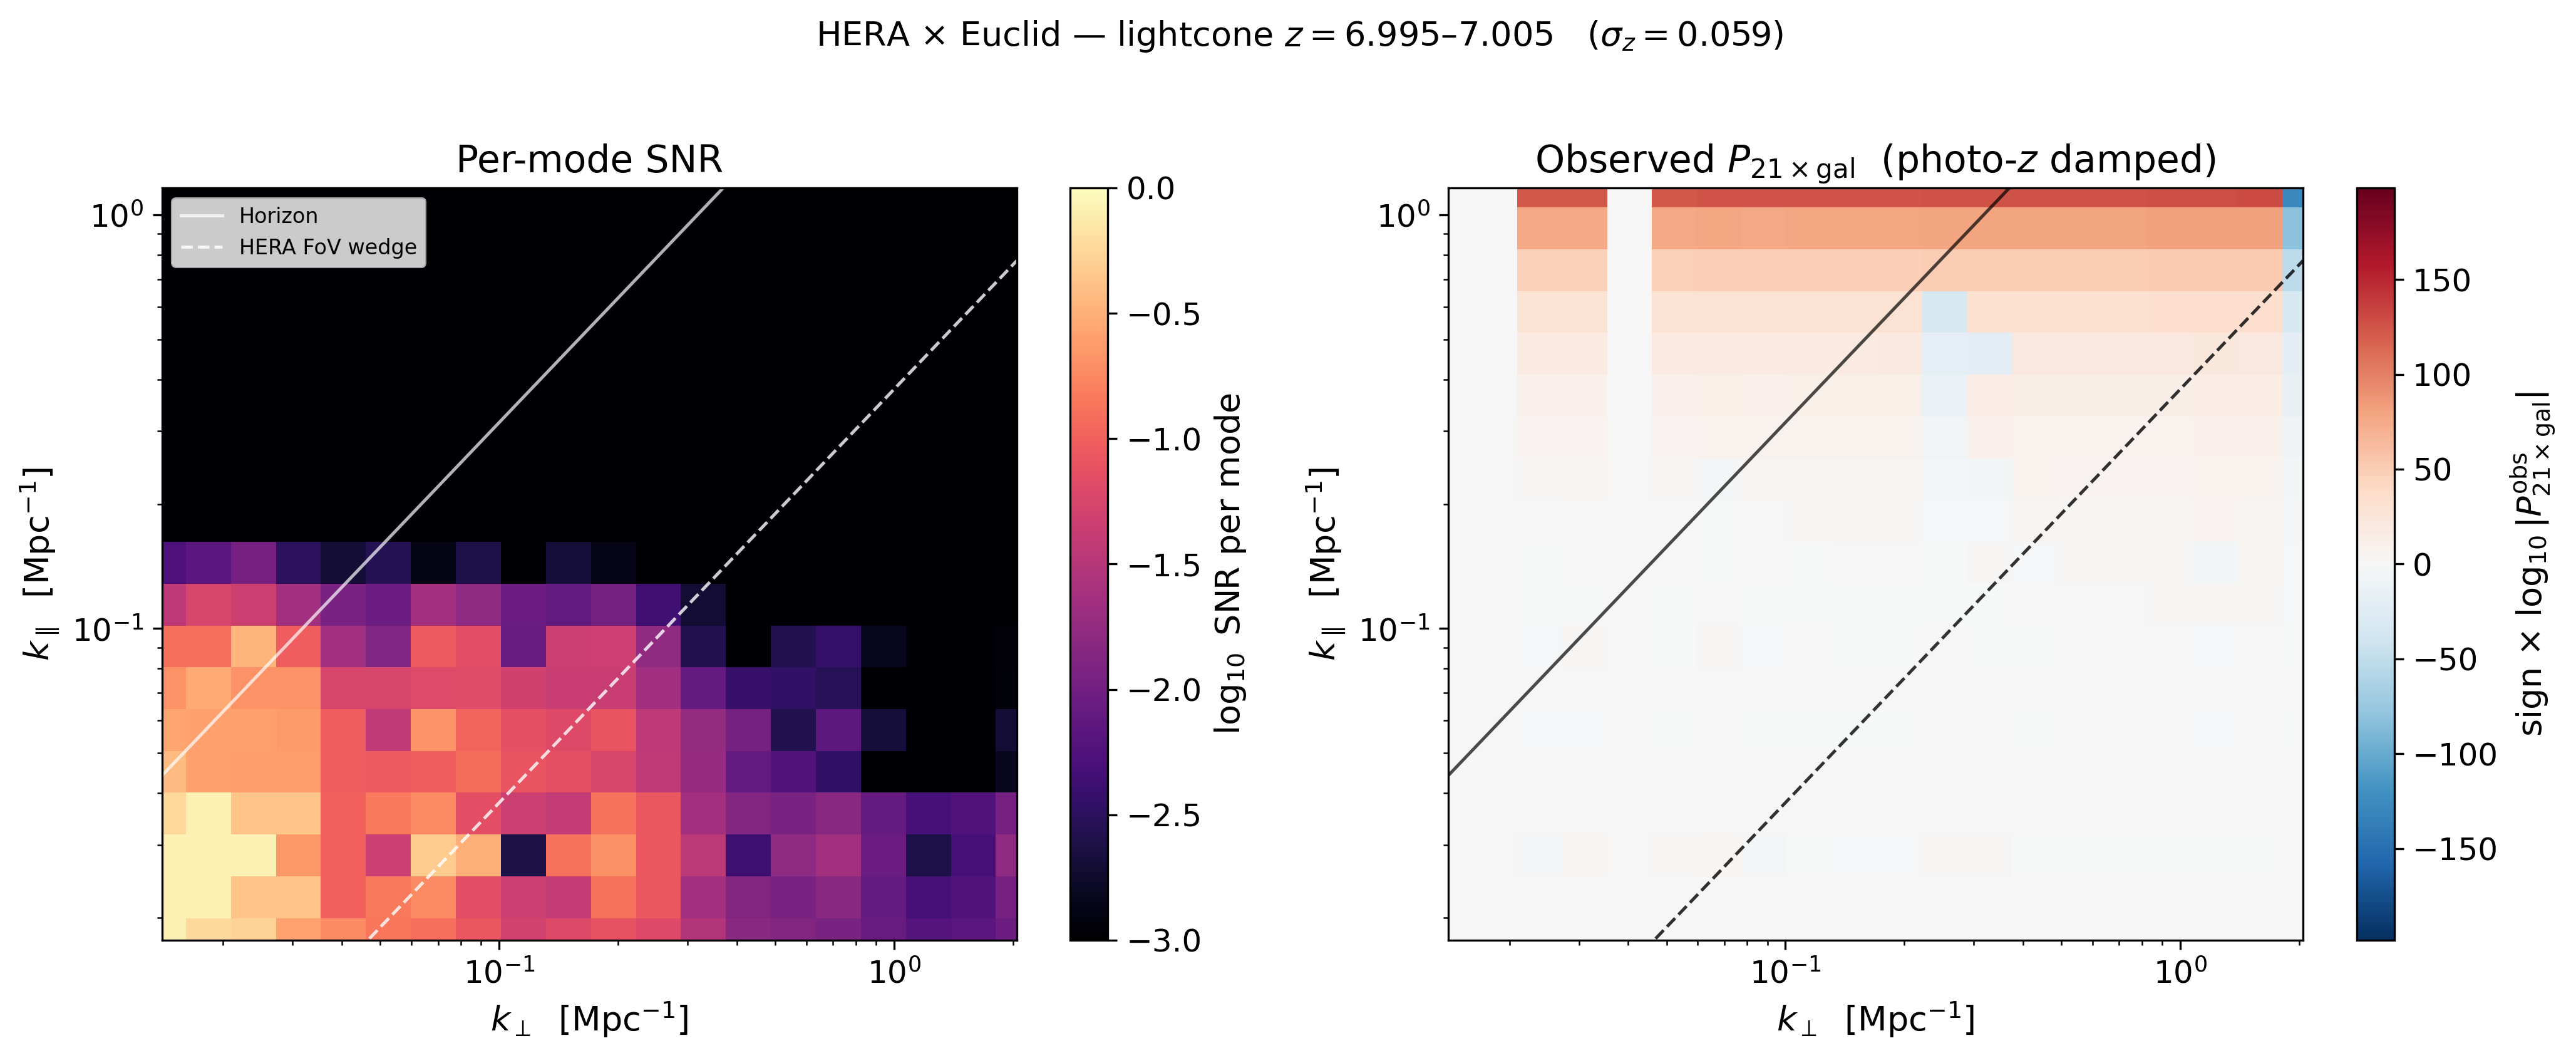


Total cross-correlation SNR (outside wedge): 0.0 σ
Detection (> 5σ) ?  NO


In [11]:
# ── 21 cm thermal noise (simplified HERA-like estimate) ──────────────────
observed_frequency = 1.42e9 / (1 + z_obs)   # Hz
system_temperature = (
    100 + 60 * (300e6 / observed_frequency)**2.55
) * 1e3   # mK

P_noise_21cm = (
    system_temperature**2 * 1e3 / (integration_time * bandwidth)
    * np.ones_like(P_cross)
)

# ── Galaxy shot noise ──────────────────────────────────────────────────────
P_noise_galaxy = 1.0 / mean_galaxy_density

# ── Per-mode uncertainty (La Plante et al. 2023, Eqs. 15–17) ──────────────
sigma_21cm   = np.abs(P_21cm_auto)       + P_noise_21cm
sigma_galaxy = np.abs(P_galaxy_observed) + P_noise_galaxy
sigma_cross  = np.sqrt(
    0.5 * (P_cross_observed**2 + sigma_21cm * sigma_galaxy)
)

# ── SNR maps ───────────────────────────────────────────────────────────────
SNR_per_mode      = np.abs(P_cross_observed) / sigma_cross
SNR_outside_wedge = np.where(outside_wedge, SNR_per_mode, np.nan)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Wedge and horizon lines for overlay
k_perp_line    = np.logspace(np.log10(k_perp.min()), np.log10(k_perp.max()), 200)
lambda_obs_    = SPEED_OF_LIGHT_KMS * 1e3 * (1 + z_obs) / F_21_HZ
horizon_slope_ = (
    lambda_obs_ * comoving_dist_obs * F_21_HZ * Hz_obs
    / (SPEED_OF_LIGHT_KMS * 1e3 * SPEED_OF_LIGHT_KMS * (1 + z_obs)**2)
)
theta_fov_  = lambda_obs_ / HERA_DISH_DIAMETER
fov_slope_  = np.sin(theta_fov_) * horizon_slope_

k_par_horizon_ = k_perp_line * horizon_slope_
k_par_fov_     = k_perp_line * fov_slope_

# Panel 1: per-mode SNR
snr_display = fill_nan_nearest(np.log10(SNR_per_mode.T))
im_snr = axes[0].pcolormesh(
    k_perp, k_parallel, snr_display,
    cmap='magma', shading='auto', vmin=-3, vmax=0,
)
fig.colorbar(im_snr, ax=axes[0], label=r"$\log_{10}$ SNR per mode")
axes[0].plot(k_perp_line, k_par_horizon_, "w-",  lw=1.2, alpha=0.7, label="Horizon")
axes[0].plot(k_perp_line, k_par_fov_,     "w--", lw=1.2, alpha=0.8, label="HERA FoV wedge")
axes[0].legend(loc='upper left', fontsize=8)
axes[0].set_title('Per-mode SNR')

# Panel 2: observed cross-power
cross_amp_  = np.abs(P_cross_observed.T)
cross_sgn_  = np.sign(P_cross_observed.T)
signed_raw_ = np.where(cross_amp_ > 0, np.log10(cross_amp_) * cross_sgn_, 0.0)
signed_log_ = fill_nan_nearest(signed_raw_)
clim_       = np.nanpercentile(np.abs(signed_log_[signed_log_ != 0]), 95)

im_cross = axes[1].pcolormesh(
    k_perp, k_parallel, signed_log_,
    cmap='RdBu_r', shading='auto', vmin=-clim_, vmax=clim_,
)
fig.colorbar(
    im_cross, ax=axes[1],
    label=r"sign $\times$ $\log_{10}|P_{21 \times \rm gal}^{\rm obs}|$",
)
axes[1].plot(k_perp_line, k_par_horizon_, "k-",  lw=1.2, alpha=0.7)
axes[1].plot(k_perp_line, k_par_fov_,     "k--", lw=1.2, alpha=0.8)
axes[1].set_title(r"Observed $P_{21 \times \rm gal}$  (photo-$z$ damped)")

for ax in axes:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r"$k_\perp$  [Mpc$^{-1}$]")
    ax.set_ylabel(r"$k_\parallel$  [Mpc$^{-1}$]")
    ax.set_xlim(k_perp[0], k_perp[-1])
    ax.set_ylim(k_parallel[0], k_parallel[-2])

plt.suptitle(
    rf"HERA $\times$ Euclid — lightcone $z = {z_min}$–${z_max}$   "
    rf"($\sigma_z = {photoz_uncertainty}$)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

# ── Total detection significance ───────────────────────────────────────────
valid_snr = SNR_per_mode[outside_wedge]
total_snr = np.sqrt(np.nansum(valid_snr**2))

print(f'\nTotal cross-correlation SNR (outside wedge): {total_snr:.1f} σ')
print(f'Detection (> 5σ) ?  {"YES" if total_snr > 5 else "NO"}')


## 5  Summary

This notebook demonstrates the post-simulation analysis for a
HERA × Euclid 21 cm–galaxy cross-correlation using a **21cmFASTv4 lightcone**:

1. **21cmFASTv4** generates a self-consistent lightcone via `RectilinearLightconer`
   + `run_lightcone`, covering $z = z_{\rm min}$–$z_{\rm max}$ in a single run
2. The **non-cubic box** $(N_\perp \times N_\perp \times N_z)$ is handled
   throughout, with separate cell sizes for the transverse and LOS directions
3. A **Euclid-like** galaxy field is extracted from the lightcone `halo_sfr`
4. The **2D cross-power spectrum** $P_{21 \times \rm gal}(k_\perp, k_\parallel)$
   is computed and shows the expected large-scale anti-correlation
5. **Photo-$z$ damping** and **foreground wedge** excision are applied at
   $z_{\rm obs}$
6. The **SNR map** identifies which Fourier modes drive the detection

### Key differences vs. the coeval version

| Feature | Coeval | Lightcone |
|---|---|---|
| 21cmFAST function | `run_coeval` | `run_lightcone` |
| Box shape | $(N, N, N)$ | $(N, N, N_z)$ |
| Redshift | single snapshot | continuous $z_{\rm min}$–$z_{\rm max}$ |
| LOS cell size | same as transverse | $L_{\rm LOS}/N_z$ |
| Field access | `coeval.brightness_temp` | `lightcone.lightcones['brightness_temp']` |
| Neutral fraction | `coeval.xH_box` | `lightcone.lightcones['neutral_fraction']` |

### To improve for publication

- Use larger boxes (1 Gpc, 2 Mpc cells) as in Davies et al. (2025)
- Replace simplified noise with [21cmSense](https://github.com/rasg-affiliates/21cmSense)
- Enable `apply_rsds=True` in `generate_lightcone` for self-consistent RSDs
- Sweep over $\sigma_z$ and magnitude limits to optimise survey design

### References

- Davies, Mesinger & Murray (2025) — [arXiv:2504.17254](https://arxiv.org/abs/2504.17254)
- Gagnon-Hartman, Davies & Mesinger (2025) — [arXiv:2502.20447](https://arxiv.org/abs/2502.20447)
- La Plante et al. (2023) — [arXiv:2205.09770](https://arxiv.org/abs/2205.09770)
- Murray, Greig & Mesinger (2020) — [JOSS 5(54)](https://doi.org/10.21105/joss.02582)
